# Part 2 — Exploratory Data Analysis

## 2. Exploratory Data Analysis

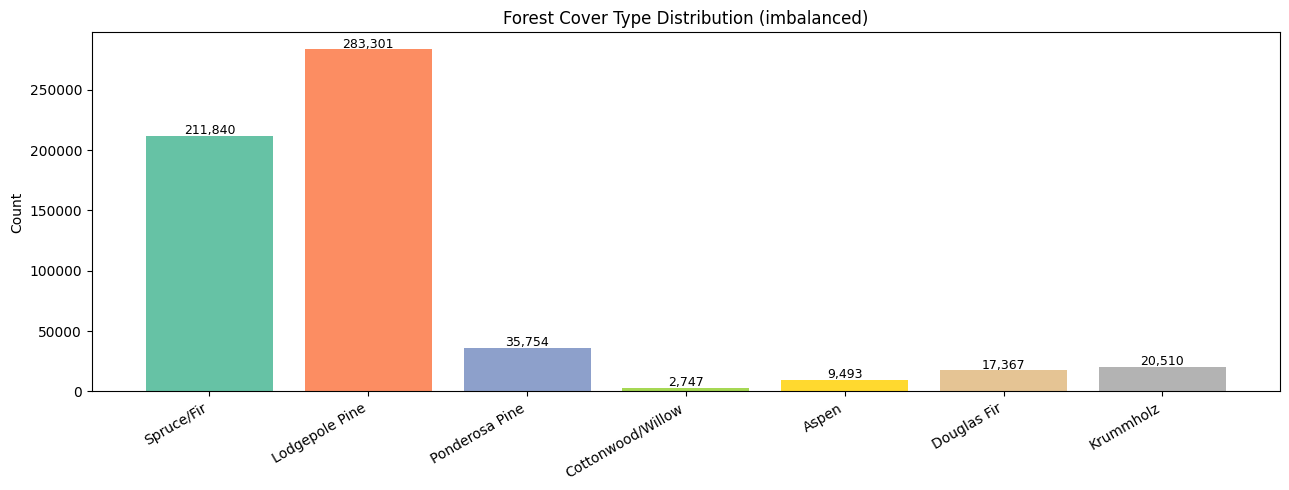

Dataset is heavily imbalanced:
  Largest  class (Lodgepole Pine) : 283,301 samples
  Smallest class (Cottonwood/Willow):   2,747 samples
  Ratio: 103x


In [2]:
# Class distribution
plt.figure(figsize=(13, 5))
counts = df['Cover_Type'].value_counts().sort_index()
colors = plt.cm.Set2(np.linspace(0, 1, 7))
bars = plt.bar([COVER_NAMES[i] for i in counts.index], counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
             f'{val:,}', ha='center', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.ylabel('Count')
plt.title('Forest Cover Type Distribution (imbalanced)')
plt.tight_layout()
plt.show()

print("Dataset is heavily imbalanced:")
print(f"  Largest  class (Lodgepole Pine) : 283,301 samples")
print(f"  Smallest class (Cottonwood/Willow):   2,747 samples")
print(f"  Ratio: {283301/2747:.0f}x")

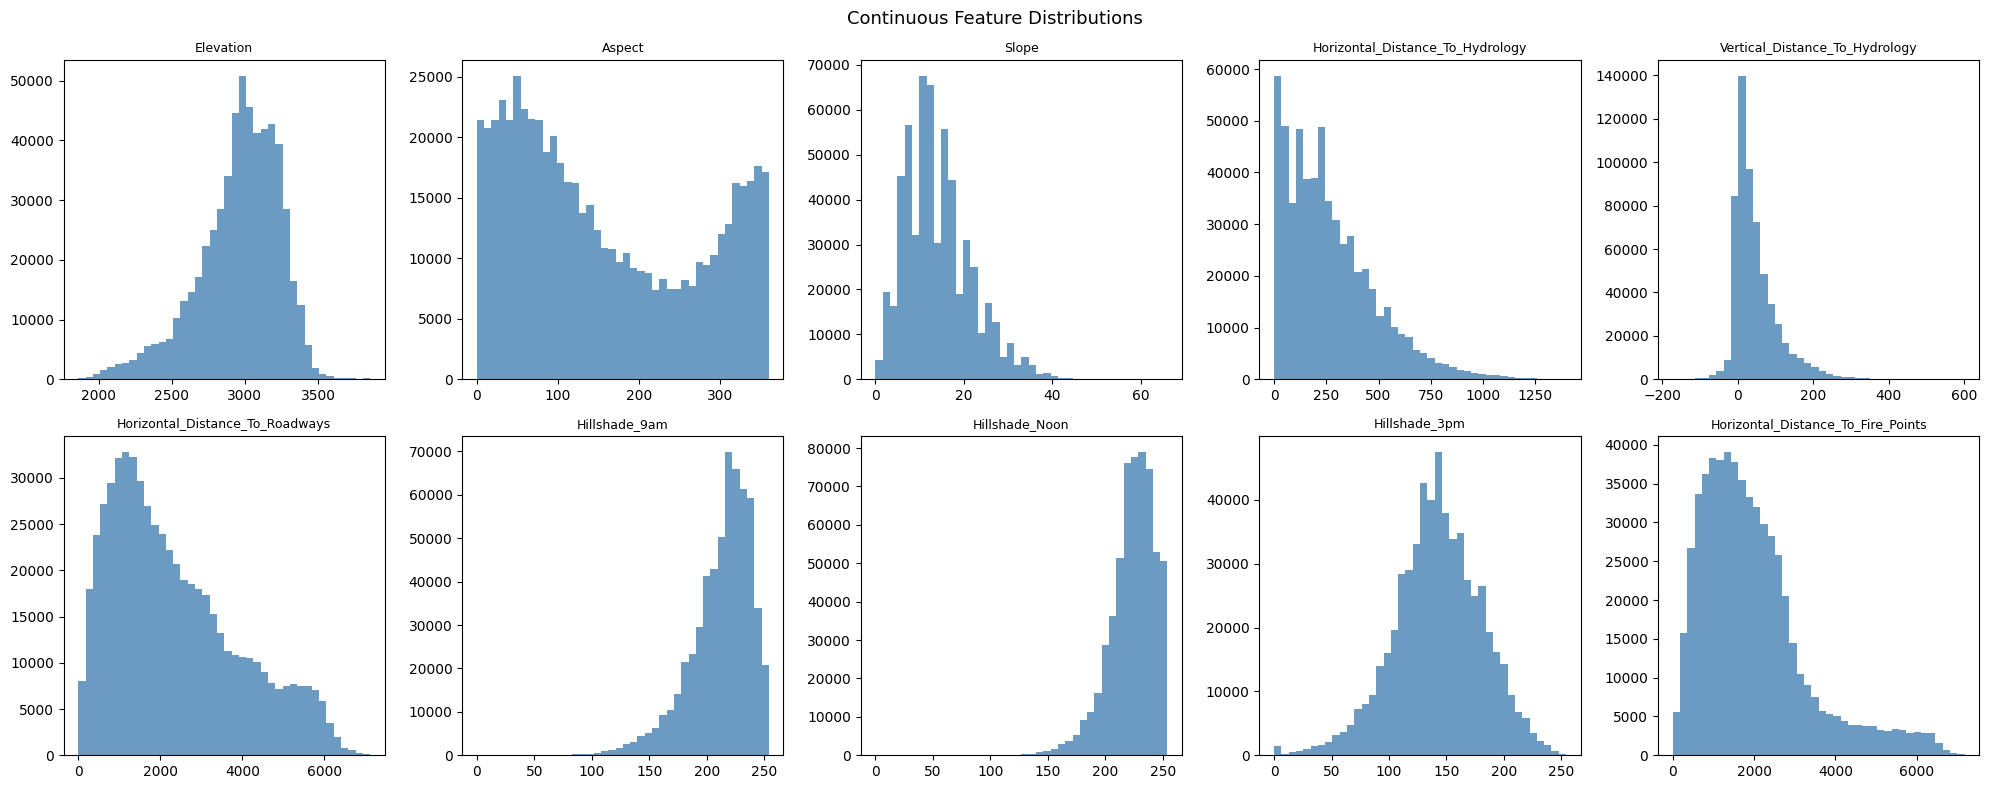

In [3]:
# Continuous feature distributions
continuous_cols = ['Elevation', 'Aspect', 'Slope',
                   'Horizontal_Distance_To_Hydrology',
                   'Vertical_Distance_To_Hydrology',
                   'Horizontal_Distance_To_Roadways',
                   'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
                   'Horizontal_Distance_To_Fire_Points']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
plt.suptitle('Continuous Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

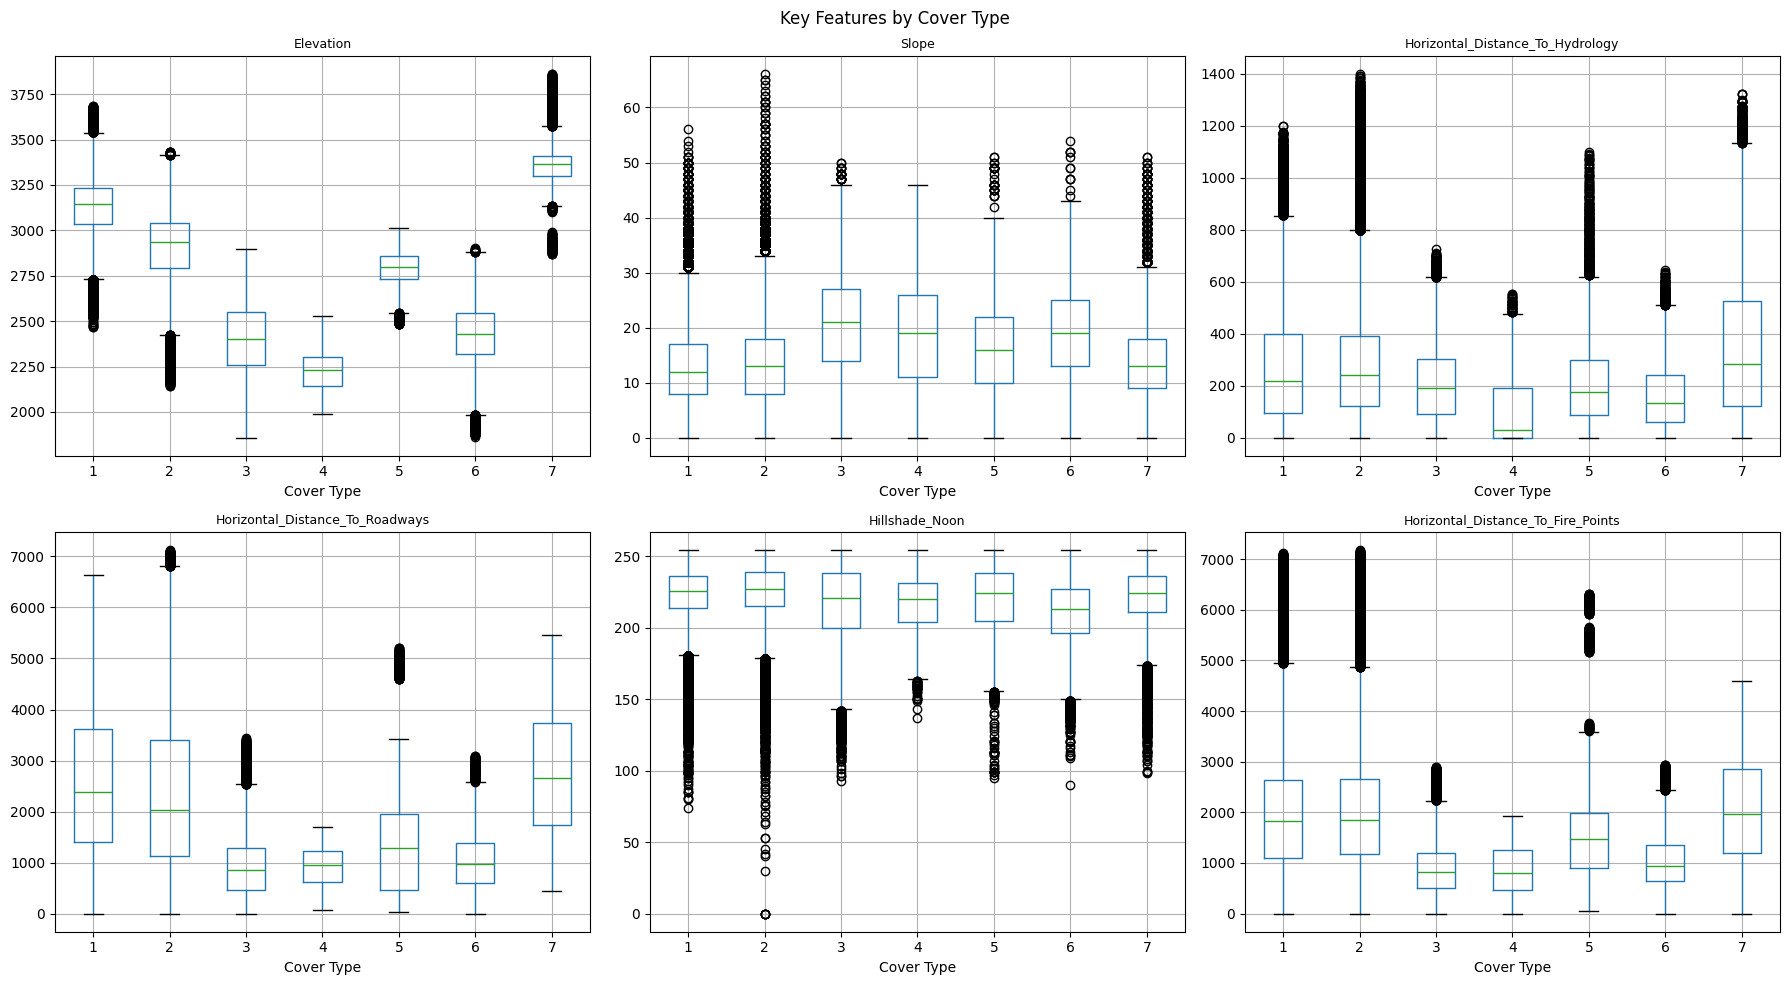

In [4]:
# Boxplots of key features by cover type
key_cols = ['Elevation', 'Slope', 'Horizontal_Distance_To_Hydrology',
            'Horizontal_Distance_To_Roadways', 'Hillshade_Noon',
            'Horizontal_Distance_To_Fire_Points']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    df.boxplot(column=col, by='Cover_Type', ax=axes[i])
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Cover Type')
plt.suptitle('Key Features by Cover Type')
plt.tight_layout()
plt.show()

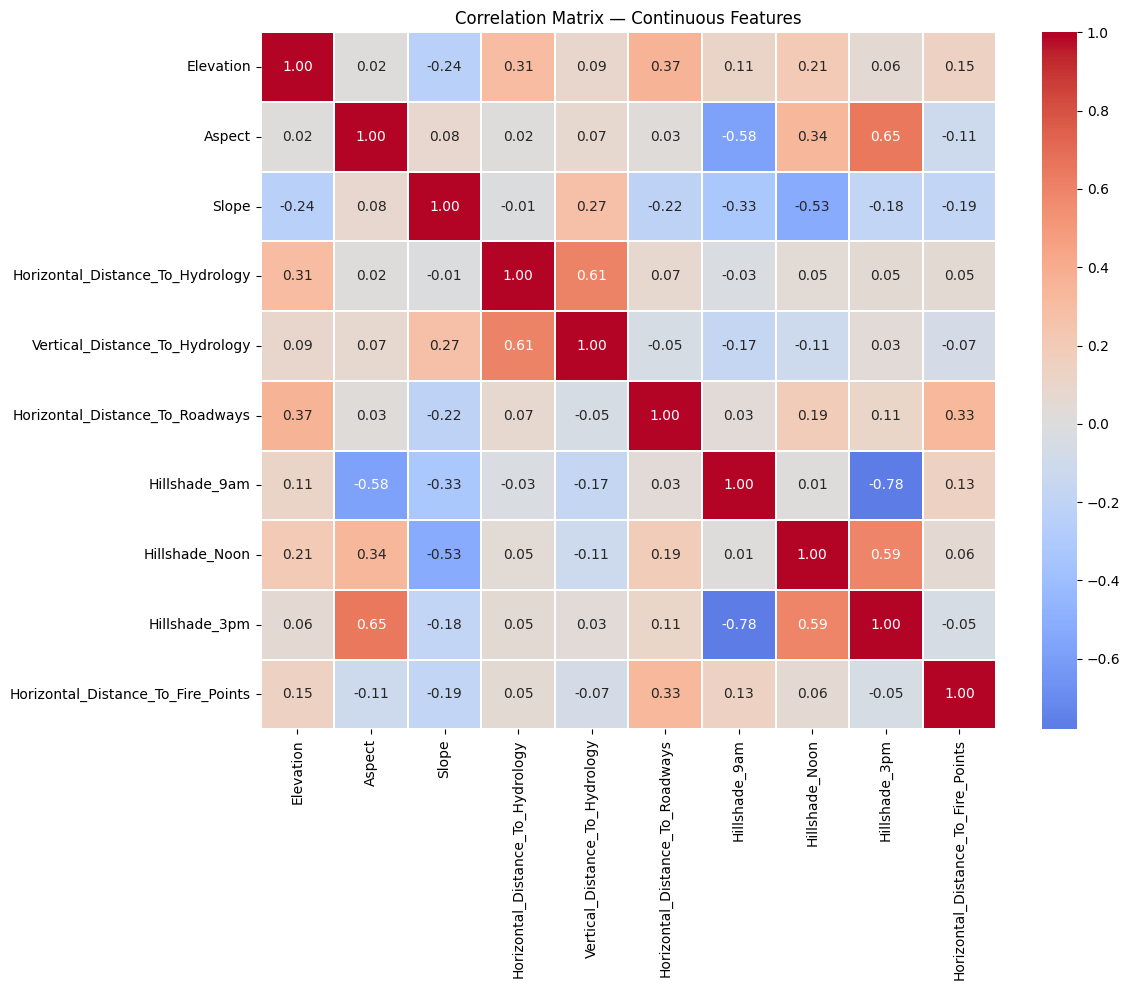

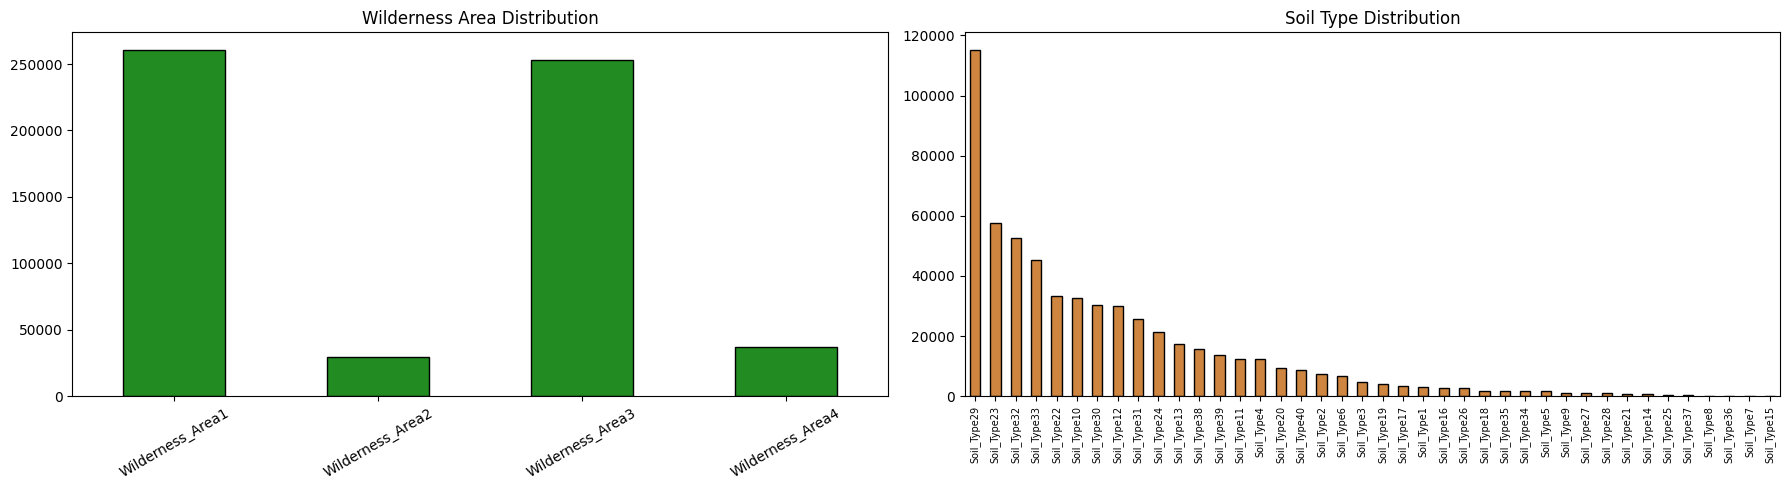

In [5]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df[continuous_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Matrix — Continuous Features')
plt.tight_layout()
plt.show()

# Wilderness & Soil type distributions
wilderness_cols = [c for c in df.columns if 'Wilderness' in c]
soil_cols       = [c for c in df.columns if 'Soil_Type' in c]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
df[wilderness_cols].sum().plot(kind='bar', color='forestgreen', edgecolor='black', ax=axes[0])
axes[0].set_title('Wilderness Area Distribution')
axes[0].tick_params(axis='x', rotation=30)

df[soil_cols].sum().sort_values(ascending=False).plot(
    kind='bar', color='peru', edgecolor='black', ax=axes[1])
axes[1].set_title('Soil Type Distribution')
axes[1].tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()